# Gene Comparison Across AMR Databases

Comparing genes across **ResLit**, **ResFinder**, **CARD**, and **Reference Gene Catalog** using the full pre-compiled gene lists.

In [32]:
#!pip install matplotlib-venn



In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from itertools import combinations
import numpy as np

other_db = pd.read_csv('/home/argis/Desktop/austin/reslit/site/paper/other_databases/comparison/genes/Full_list_genes_otherDatabases_AlleleCorrected-1_filtered_concatenated_bla_fixed_pubmed_antibiotic_corrected.csv')
reslit_db = pd.read_csv('/home/argis/Desktop/austin/reslit/site/paper/other_databases/comparison/genes/Full_list_genes_Reslit_harmonized_antib_bact.csv')

print(f"Other databases rows: {len(other_db)}")
print(f"ResLit rows: {len(reslit_db)}")
print(f"\nDatabases in other file: {other_db['Database'].unique()}")
print(f"Databases in ResLit file: {reslit_db['Database'].unique()}")

Other databases rows: 22082
ResLit rows: 54181

Databases in other file: ['Reference Gene Catalog' 'ResFinder Database' 'Card Database']
Databases in ResLit file: ['Reslit']


In [8]:
def normalize_gene_name(name):
    if pd.isna(name):
        return name
    
    return name

# Extract unique normalized gene sets per database
resfinder_df = other_db[other_db['Database'] == 'ResFinder Database']
card_df = other_db[other_db['Database'] == 'Card Database']
refcat_df = other_db[other_db['Database'] == 'Reference Gene Catalog']

genes_reslit = set(reslit_db['Gene'].dropna().apply(normalize_gene_name).unique())
genes_resfinder = set(resfinder_df['Gene'].dropna().apply(normalize_gene_name).unique())
genes_card = set(card_df['Gene'].dropna().apply(normalize_gene_name).unique())
genes_refcat = set(refcat_df['Gene'].dropna().apply(normalize_gene_name).unique())

print(f"Unique genes per database (normalized):")
print(f"  ResLit:                 {len(genes_reslit)}")
print(f"  ResFinder:              {len(genes_resfinder)}")
print(f"  CARD:                   {len(genes_card)}")
print(f"  Reference Gene Catalog: {len(genes_refcat)}")

Unique genes per database (normalized):
  ResLit:                 2546
  ResFinder:              638
  CARD:                   1272
  Reference Gene Catalog: 1138


In [3]:
def normalize_gene_name(name):
    if pd.isna(name):
        return name
    name = str(name).lower().strip()
    name = (name.replace('′', '')   # prime
                .replace('ʹ', '')   # modifier letter prime
                .replace('‘', '')   # left single quote
                .replace('’', '')   # right single quote
                .replace('`', '')   # backtick
                .replace('´', '')   # acute accent
                .replace("'", '')
                .replace('"', ''))
    return name

# Extract unique normalized gene sets per database
resfinder_df = other_db[other_db['Database'] == 'ResFinder Database']
card_df = other_db[other_db['Database'] == 'Card Database']
refcat_df = other_db[other_db['Database'] == 'Reference Gene Catalog']

genes_reslit = set(reslit_db['Gene'].dropna().apply(normalize_gene_name).unique())
genes_resfinder = set(resfinder_df['Gene'].dropna().apply(normalize_gene_name).unique())
genes_card = set(card_df['Gene'].dropna().apply(normalize_gene_name).unique())
genes_refcat = set(refcat_df['Gene'].dropna().apply(normalize_gene_name).unique())

print(f"Unique genes per database (normalized):")
print(f"  ResLit:                 {len(genes_reslit)}")
print(f"  ResFinder:              {len(genes_resfinder)}")
print(f"  CARD:                   {len(genes_card)}")
print(f"  Reference Gene Catalog: {len(genes_refcat)}")

Unique genes per database (normalized):
  ResLit:                 2545
  ResFinder:              635
  CARD:                   1210
  Reference Gene Catalog: 1133


## Pairwise Comparisons

In [9]:
db_sets = {
    'ResLit': genes_reslit,
    'ResFinder': genes_resfinder,
    'CARD': genes_card,
    'Ref Gene Catalog': genes_refcat
}

print("=" * 70)
print("PAIRWISE OVERLAP")
print("=" * 70)

for (name_a, set_a), (name_b, set_b) in combinations(db_sets.items(), 2):
    common = set_a & set_b
    only_a = set_a - set_b
    only_b = set_b - set_a
    print(f"\n{name_a} vs {name_b}:")
    print(f"  Common genes:       {len(common)}")
    print(f"  Only in {name_a:20s}: {len(only_a)}")
    print(f"  Only in {name_b:20s}: {len(only_b)}")

PAIRWISE OVERLAP

ResLit vs ResFinder:
  Common genes:       537
  Only in ResLit              : 2009
  Only in ResFinder           : 101

ResLit vs CARD:
  Common genes:       885
  Only in ResLit              : 1661
  Only in CARD                : 387

ResLit vs Ref Gene Catalog:
  Common genes:       840
  Only in ResLit              : 1706
  Only in Ref Gene Catalog    : 298

ResFinder vs CARD:
  Common genes:       538
  Only in ResFinder           : 100
  Only in CARD                : 734

ResFinder vs Ref Gene Catalog:
  Common genes:       559
  Only in ResFinder           : 79
  Only in Ref Gene Catalog    : 579

CARD vs Ref Gene Catalog:
  Common genes:       890
  Only in CARD                : 382
  Only in Ref Gene Catalog    : 248


In [5]:
db_sets = {
    'ResLit': genes_reslit,
    'ResFinder': genes_resfinder,
    'CARD': genes_card,
    'Ref Gene Catalog': genes_refcat
}

print("=" * 70)
print("PAIRWISE OVERLAP")
print("=" * 70)

for (name_a, set_a), (name_b, set_b) in combinations(db_sets.items(), 2):
    common = set_a & set_b
    only_a = set_a - set_b
    only_b = set_b - set_a
    print(f"\n{name_a} vs {name_b}:")
    print(f"  Common genes:       {len(common)}")
    print(f"  Only in {name_a:20s}: {len(only_a)}")
    print(f"  Only in {name_b:20s}: {len(only_b)}")

PAIRWISE OVERLAP

ResLit vs ResFinder:
  Common genes:       537
  Only in ResLit              : 2008
  Only in ResFinder           : 98

ResLit vs CARD:
  Common genes:       932
  Only in ResLit              : 1613
  Only in CARD                : 278

ResLit vs Ref Gene Catalog:
  Common genes:       841
  Only in ResLit              : 1704
  Only in Ref Gene Catalog    : 292

ResFinder vs CARD:
  Common genes:       538
  Only in ResFinder           : 97
  Only in CARD                : 672

ResFinder vs Ref Gene Catalog:
  Common genes:       557
  Only in ResFinder           : 78
  Only in Ref Gene Catalog    : 576

CARD vs Ref Gene Catalog:
  Common genes:       891
  Only in CARD                : 319
  Only in Ref Gene Catalog    : 242


## Multi-Database Overlap (all 4 databases)

In [10]:
all_four = genes_reslit & genes_resfinder & genes_card & genes_refcat
three_no_reslit = genes_resfinder & genes_card & genes_refcat - genes_reslit
three_no_resfinder = genes_reslit & genes_card & genes_refcat - genes_resfinder
three_no_card = genes_reslit & genes_resfinder & genes_refcat - genes_card
three_no_refcat = genes_reslit & genes_resfinder & genes_card - genes_refcat

only_reslit = genes_reslit - genes_resfinder - genes_card - genes_refcat
only_resfinder = genes_resfinder - genes_reslit - genes_card - genes_refcat
only_card = genes_card - genes_reslit - genes_resfinder - genes_refcat
only_refcat = genes_refcat - genes_reslit - genes_resfinder - genes_card

all_genes = genes_reslit | genes_resfinder | genes_card | genes_refcat

print(f"Total unique genes across all 4 databases: {len(all_genes)}")
print(f"\nGenes in ALL 4 databases: {len(all_four)}")
print(f"\nGenes UNIQUE to each database:")
print(f"  Only in ResLit:             {len(only_reslit)}")
print(f"  Only in ResFinder:          {len(only_resfinder)}")
print(f"  Only in CARD:               {len(only_card)}")
print(f"  Only in Ref Gene Catalog:   {len(only_refcat)}")

# In at least 2, 3, 4 databases
membership = []
for gene in all_genes:
    count = sum(gene in s for s in db_sets.values())
    membership.append(count)

membership_series = pd.Series(membership)
print(f"\nGenes by number of databases they appear in:")
for n in sorted(membership_series.unique()):
    print(f"  In {n} database(s): {(membership_series == n).sum()}")

Total unique genes across all 4 databases: 3120

Genes in ALL 4 databases: 480

Genes UNIQUE to each database:
  Only in ResLit:             1540
  Only in ResFinder:          44
  Only in CARD:               224
  Only in Ref Gene Catalog:   133

Genes by number of databases they appear in:
  In 1 database(s): 1941
  In 2 database(s): 364
  In 3 database(s): 335
  In 4 database(s): 480


## Venn Diagrams

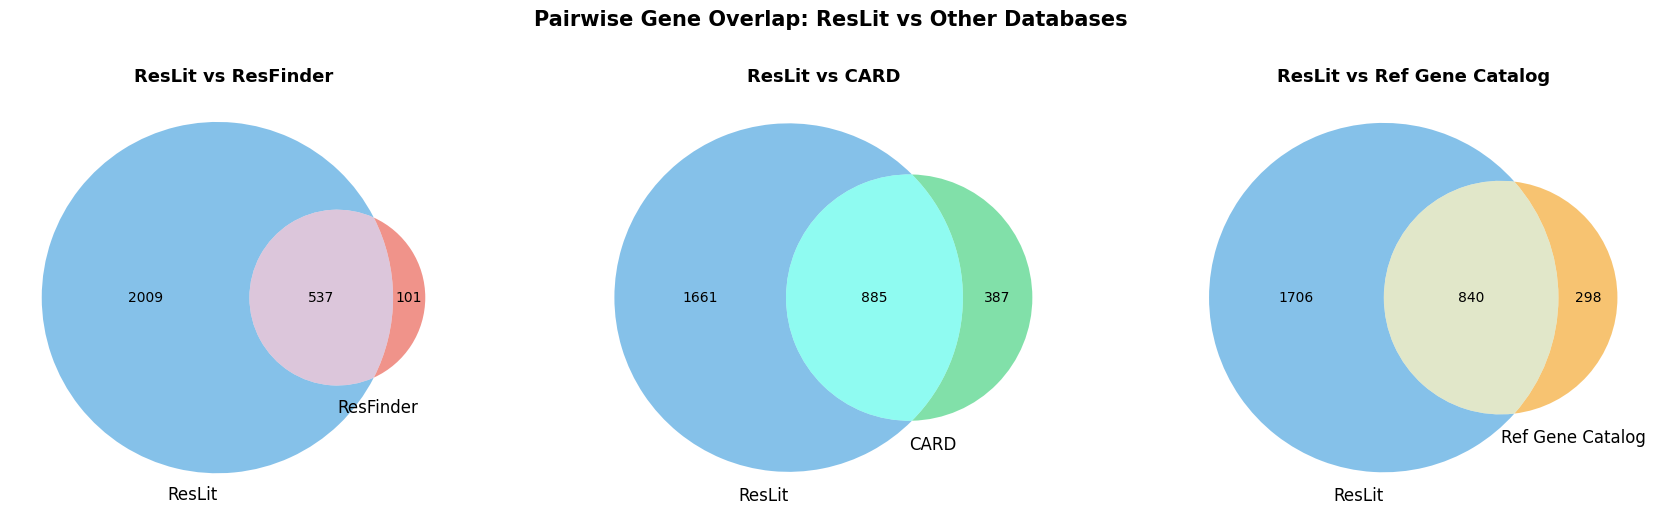

In [11]:
# ResLit vs each other database
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

others = [('ResFinder', genes_resfinder), ('CARD', genes_card), ('Ref Gene Catalog', genes_refcat)]
colors = [('#3498db', '#e74c3c'), ('#3498db', '#2ecc71'), ('#3498db', '#f39c12')]

for ax, (name, gene_set), (c1, c2) in zip(axes, others, colors):
    v = venn2([genes_reslit, gene_set], set_labels=('ResLit', name), ax=ax,
              set_colors=(c1, c2), alpha=0.6)
    ax.set_title(f'ResLit vs {name}', fontsize=13, fontweight='bold')

plt.suptitle('Pairwise Gene Overlap: ResLit vs Other Databases', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

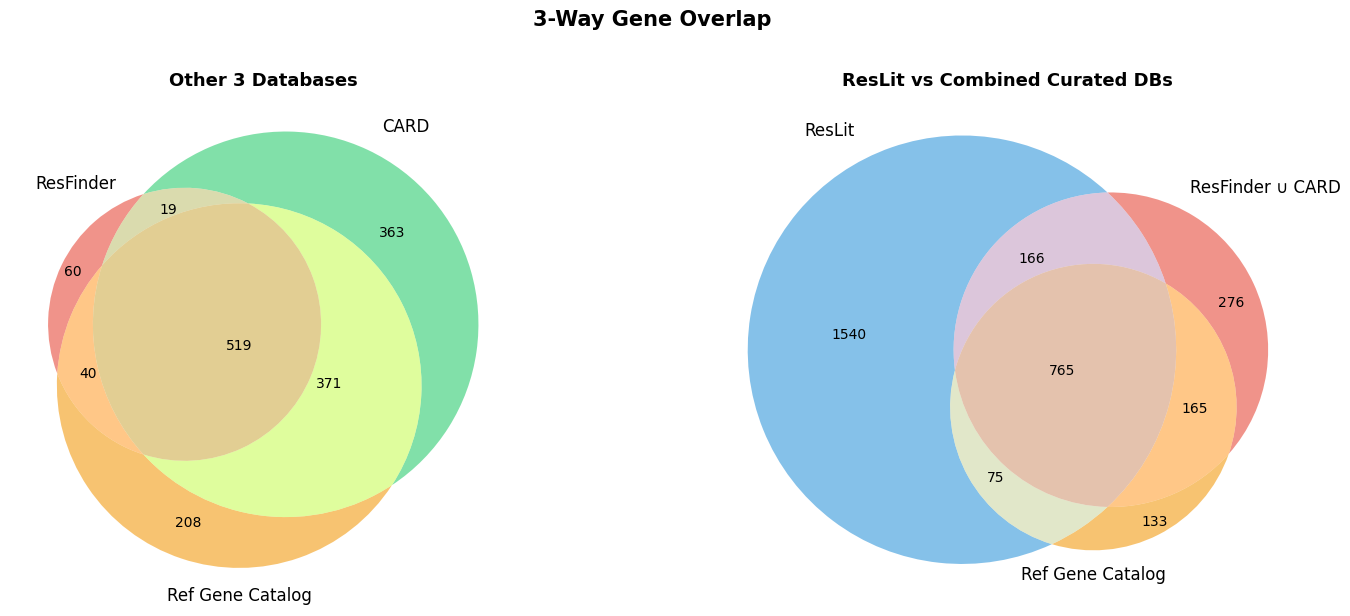

In [12]:
# 3-way Venn: ResFinder, CARD, Reference Gene Catalog
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

v3 = venn3([genes_resfinder, genes_card, genes_refcat],
           set_labels=('ResFinder', 'CARD', 'Ref Gene Catalog'),
           set_colors=('#e74c3c', '#2ecc71', '#f39c12'), alpha=0.6, ax=axes[0])
axes[0].set_title('Other 3 Databases', fontsize=13, fontweight='bold')

# 3-way Venn: ResLit vs combined-other vs each
other_combined = genes_resfinder | genes_card | genes_refcat
v3b = venn3([genes_reslit, genes_resfinder | genes_card, genes_refcat],
            set_labels=('ResLit', 'ResFinder ∪ CARD', 'Ref Gene Catalog'),
            set_colors=('#3498db', '#e74c3c', '#f39c12'), alpha=0.6, ax=axes[1])
axes[1].set_title('ResLit vs Combined Curated DBs', fontsize=13, fontweight='bold')

plt.suptitle('3-Way Gene Overlap', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## UpSet-Style Intersection Breakdown (all 4 databases)

In [13]:
db_names = ['ResLit', 'ResFinder', 'CARD', 'Ref Gene Catalog']
db_gene_sets = [genes_reslit, genes_resfinder, genes_card, genes_refcat]

# Compute all 2^4 - 1 = 15 non-empty intersection regions
from itertools import product

intersection_counts = {}
for combo in product([False, True], repeat=4):
    if not any(combo):
        continue
    label = tuple(db_names[i] for i in range(4) if combo[i])
    result = set(all_genes)
    for i in range(4):
        if combo[i]:
            result &= db_gene_sets[i]
        else:
            result -= db_gene_sets[i]
    if len(result) > 0:
        intersection_counts[label] = len(result)

# Sort by count descending
sorted_intersections = sorted(intersection_counts.items(), key=lambda x: -x[1])

print(f"{'Databases':<60s} {'Count':>6s}")
print("=" * 68)
for label, count in sorted_intersections:
    print(f"{' ∩ '.join(label):<60s} {count:>6d}")

Databases                                                     Count
ResLit                                                         1540
ResLit ∩ ResFinder ∩ CARD ∩ Ref Gene Catalog                    480
ResLit ∩ CARD ∩ Ref Gene Catalog                                255
CARD                                                            224
ResLit ∩ CARD                                                   139
Ref Gene Catalog                                                133
CARD ∩ Ref Gene Catalog                                         116
ResLit ∩ Ref Gene Catalog                                        75
ResFinder                                                        44
ResFinder ∩ CARD ∩ Ref Gene Catalog                              39
ResLit ∩ ResFinder ∩ Ref Gene Catalog                            30
ResLit ∩ ResFinder                                               16
ResLit ∩ ResFinder ∩ CARD                                        11
ResFinder ∩ Ref Gene Catalog                    

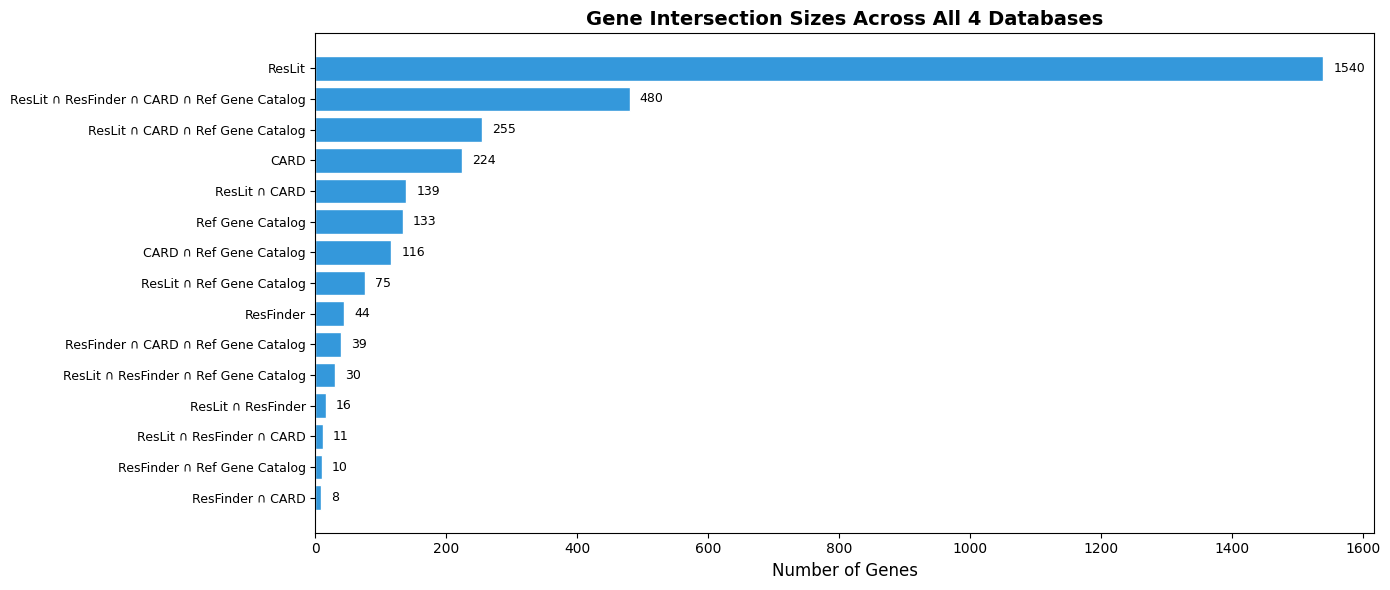

In [14]:
# UpSet-style bar chart
labels = [' ∩ '.join(l) for l, _ in sorted_intersections]
counts = [c for _, c in sorted_intersections]

fig, ax = plt.subplots(figsize=(14, max(6, len(labels) * 0.4)))
bars = ax.barh(range(len(labels)), counts, color='#3498db', edgecolor='white')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of Genes', fontsize=12)
ax.set_title('Gene Intersection Sizes Across All 4 Databases', fontsize=14, fontweight='bold')

for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + max(counts) * 0.01, bar.get_y() + bar.get_height() / 2,
            str(count), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Sample of Genes Common to All 4 Databases

In [43]:
all_four_sorted = sorted(all_four)
print(f"Total genes in all 4 databases: {len(all_four_sorted)}")
print(f"\nFirst 50 genes common to all 4 databases:")
for i, gene in enumerate(all_four_sorted[:50], 1):
    print(f"  {i:3d}. {gene}")

Total genes in all 4 databases: 481

First 50 genes common to all 4 databases:
    1. aac(2)-ia
    2. aac(2)-ib
    3. aac(2)-ic
    4. aac(2)-id
    5. aac(2)-ie
    6. aac(2)-iia
    7. aac(3)-ia
    8. aac(3)-ib
    9. aac(3)-ic
   10. aac(3)-id
   11. aac(3)-iia
   12. aac(3)-iib
   13. aac(3)-iic
   14. aac(3)-iid
   15. aac(3)-iie
   16. aac(3)-iiia
   17. aac(3)-iiib
   18. aac(3)-iva
   19. aac(3)-ixa
   20. aac(3)-via
   21. aac(3)-viia
   22. aac(3)-viii
   23. aac(3)-xa
   24. aac(6)
   25. aac(6)-30
   26. aac(6)-31
   27. aac(6)-i
   28. aac(6)-ia
   29. aac(6)-iad
   30. aac(6)-iak
   31. aac(6)-ian
   32. aac(6)-ib
   33. aac(6)-ib-cr
   34. aac(6)-ib11
   35. aac(6)-ie/aph(2)
   36. aac(6)-if
   37. aac(6)-iia
   38. aac(6)-iic
   39. aac(6)-il
   40. aac(6)-im
   41. aac(6)-ip
   42. aac(6)-iq
   43. aac(6)-iz
   44. aaca43
   45. aada1
   46. aada10
   47. aada11
   48. aada12
   49. aada13
   50. aada15


## Export Results

In [44]:
# Build a dataframe with each gene and which databases it appears in
rows = []
for gene in sorted(all_genes):
    rows.append({
        'gene': gene,
        'in_ResLit': gene in genes_reslit,
        'in_ResFinder': gene in genes_resfinder,
        'in_CARD': gene in genes_card,
        'in_RefGeneCatalog': gene in genes_refcat,
        'num_databases': sum([
            gene in genes_reslit,
            gene in genes_resfinder,
            gene in genes_card,
            gene in genes_refcat
        ])
    })

result_df = pd.DataFrame(rows)
result_df.to_csv('gene_database_membership.csv', index=False)
print(f"Saved {len(result_df)} genes to 'gene_database_membership.csv'")
print(f"\nBreakdown:")
print(result_df['num_databases'].value_counts().sort_index().to_string())

Saved 4151 genes to 'gene_database_membership.csv'

Breakdown:
num_databases
1    2912
2     411
3     347
4     481
